# Multi-Depot Vehicle Routing Problem (with clustering)
---
Description:

The Multi-Depot Vehicle Routing Problem (MDVRP) is an extension of the Vehicle Routing Problem where a fleet of vehicles is based at 
multiple depots and must serve a set of customers with known demands. The objective is to assign customers to depots and design routes
for vehicles (respecting capacity, time-window, and route-length constraints) that minimize total cost (e.g., distance or time), while 
ensuring all customer demands are satisfied and each route starts and ends at the same depot.

- Optimization (combinatorial)
- Single-objective
- Constraints (yes)
---

### Import python libraries and set up the project directory

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = os.path.abspath('../../')

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

# Multi Depot Vehicles Routing Problem.
from utils import (load_data, Cluster,
                   initialize_population, cluster_customers_to_depots,
                   evaluate_solution)

### Import the custom GA code

In [2]:
# Import main classes.
from pygenalgo.genome.chromosome import Chromosome
from pygenalgo.utils.utilities import cost_function
from pygenalgo.engines.standard_ga import StandardGA

# Import Selection Operator(s).
from pygenalgo.operators.selection.tournament_selector import TournamentSelector

# Import Crossover Operator(s).
from pygenalgo.operators.crossover.order_crossover import OrderCrossover

# Import Mutation Operator(s).
from pygenalgo.operators.mutation.swap_mutator import SwapMutator

### Read the data and cluster the customers to the depots

In [3]:
# Select a datafile.
# p01_c50_d4_v4
# p02_c50_d4_v2
# p03_c31_d1_v5
filepath = "data/p01_c50_d4_v4.json"

# Load the data from the filepath.
CUSTOMERS, DEPOTS = load_data(filepath)

# Create and store the clusters.
depot_clusters = cluster_customers_to_depots(DEPOTS,
                                             CUSTOMERS,
                                             verbose=True)

Depot-ID: 51 has  13 customers
Depot-ID: 52 has  17 customers
Depot-ID: 53 has  11 customers
Depot-ID: 54 has   9 customers


### Setup the fitness function

In [4]:
# Define the fitness function.
@cost_function(minimize=True)
def func_MDVRP(individual: Chromosome, cluster: Cluster) -> tuple[float, bool]:
    """
    This function computes the total distance
    travelled from all the cars of each depot.
    """
    # Validate the solution.
    total_distance, total_penalty = evaluate_solution(individual, cluster)
    
    # Penalty coefficient.
    p_coeff = 5.0
    
    # Estimate the fitness value.
    f_value = total_distance + (p_coeff * total_penalty)
    
    # Return the total fitness.
    return f_value, False
# _end_def_

In [5]:
# Total distance and penalty values.
total_d, total_p = 0.0, 0

# Store the solutions for plotting.
optimal_solutions = []

# Process all clusters (serially).
for cluster_k in depot_clusters:
    # Extract the depot.
    depot_k = cluster_k.depot
    
    # Extract the customers.
    customers_k = cluster_k.customers
    
    # Create the initial population.
    population_k = initialize_population(customers_k,
                                         depot_k.vehicles,
                                         n_pop=100)
    # Create a StandardGA object.
    test_GA = StandardGA(initial_pop=population_k,
                         fit_func=lambda x: func_MDVRP(x, cluster_k),
                         select_op=TournamentSelector(),
                         crossx_op=OrderCrossover(0.8),
                         mutate_op=SwapMutator(0.2))

    # Optimize the model.
    test_GA(epochs=800, elitism=True, verbose=True)
    
    # Extract the optimal solution from the GA.
    optimal_k = test_GA.best_chromosome()

    # Display an empty line.
    print(" ")
    
    # Extract the validation values.
    dist_k, pnlt_k = evaluate_solution(optimal_k, cluster_k,
                                       verbose=True)
    # Add the output values.
    total_d += dist_k
    total_p += pnlt_k

    # Store the optimal_k solution.
    optimal_solutions.append(optimal_k)

07/16/2026 09:32:56 INFO: Initial Avg. Fitness = -336.2661
07/16/2026 09:32:56 INFO: Epoch:     1 -> Avg. Fitness = -306.7816, Spread = 58.3745
07/16/2026 09:32:57 INFO: Epoch:    81 -> Avg. Fitness = -190.5559, Spread = 21.4823
07/16/2026 09:32:58 INFO: Epoch:   161 -> Avg. Fitness = -185.7128, Spread = 17.8903
07/16/2026 09:32:59 INFO: Epoch:   241 -> Avg. Fitness = -183.1809, Spread = 16.8063
07/16/2026 09:33:00 INFO: Epoch:   321 -> Avg. Fitness = -198.7950, Spread = 33.4187
07/16/2026 09:33:01 INFO: Epoch:   401 -> Avg. Fitness = -187.9342, Spread = 20.5169
07/16/2026 09:33:02 INFO: Epoch:   481 -> Avg. Fitness = -192.2860, Spread = 31.3662
07/16/2026 09:33:03 INFO: Epoch:   561 -> Avg. Fitness = -183.4838, Spread = 17.6921
07/16/2026 09:33:04 INFO: Epoch:   641 -> Avg. Fitness = -187.4430, Spread = 21.0782
07/16/2026 09:33:05 INFO: Epoch:   721 -> Avg. Fitness = -187.8117, Spread = 19.7540
07/16/2026 09:33:06 INFO: Final   Avg. Fitness = -194.2265
07/16/2026 09:33:06 INFO: Initia

Elapsed time: 9.891 seconds.
 
Depot-ID 51: -> Route 0, Distance 51.17, Demand 51
Depot-ID 51: -> Route 1, Distance 51.75, Demand 56
Depot-ID 51: -> Route 2, Distance 48.11, Demand 48
Depot-ID 51: -> Route 3, Distance 26.96, Demand 50


07/16/2026 09:33:07 INFO: Epoch:    81 -> Avg. Fitness = -285.5418, Spread = 35.9671
07/16/2026 09:33:08 INFO: Epoch:   161 -> Avg. Fitness = -252.6102, Spread = 32.9146
07/16/2026 09:33:09 INFO: Epoch:   241 -> Avg. Fitness = -281.0612, Spread = 68.0236
07/16/2026 09:33:11 INFO: Epoch:   321 -> Avg. Fitness = -259.9325, Spread = 69.8634
07/16/2026 09:33:12 INFO: Epoch:   401 -> Avg. Fitness = -252.8198, Spread = 50.9047
07/16/2026 09:33:13 INFO: Epoch:   481 -> Avg. Fitness = -280.2052, Spread = 87.8802
07/16/2026 09:33:14 INFO: Epoch:   561 -> Avg. Fitness = -244.4176, Spread = 35.3273
07/16/2026 09:33:16 INFO: Epoch:   641 -> Avg. Fitness = -278.1286, Spread = 83.6799
07/16/2026 09:33:17 INFO: Epoch:   721 -> Avg. Fitness = -265.2367, Spread = 81.8836
07/16/2026 09:33:18 INFO: Final   Avg. Fitness = -248.1941
07/16/2026 09:33:18 INFO: Initial Avg. Fitness = -192.8059
07/16/2026 09:33:18 INFO: Epoch:     1 -> Avg. Fitness = -183.5382, Spread = 26.9622


Elapsed time: 12.289 seconds.
 
Depot-ID 52: -> Route 0, Distance 76.87, Demand 73
Depot-ID 52: -> Route 1, Distance 23.50, Demand 54
Depot-ID 52: -> Route 2, Distance 40.98, Demand 58
Depot-ID 52: -> Route 3, Distance 79.60, Demand 77


07/16/2026 09:33:19 INFO: Epoch:    81 -> Avg. Fitness = -129.0636, Spread = 26.3343
07/16/2026 09:33:20 INFO: Epoch:   161 -> Avg. Fitness = -125.2240, Spread = 22.0669
07/16/2026 09:33:21 INFO: Epoch:   241 -> Avg. Fitness = -129.1189, Spread = 23.4609
07/16/2026 09:33:21 INFO: Epoch:   321 -> Avg. Fitness = -126.8921, Spread = 20.0218
07/16/2026 09:33:22 INFO: Epoch:   401 -> Avg. Fitness = -129.3086, Spread = 23.1883
07/16/2026 09:33:23 INFO: Epoch:   481 -> Avg. Fitness = -125.3892, Spread = 18.0212
07/16/2026 09:33:24 INFO: Epoch:   561 -> Avg. Fitness = -128.3381, Spread = 23.3727
07/16/2026 09:33:25 INFO: Epoch:   641 -> Avg. Fitness = -132.1596, Spread = 24.2073
07/16/2026 09:33:26 INFO: Epoch:   721 -> Avg. Fitness = -123.2864, Spread = 16.7973
07/16/2026 09:33:26 INFO: Final   Avg. Fitness = -126.3049
07/16/2026 09:33:26 INFO: Initial Avg. Fitness = -195.9878
07/16/2026 09:33:27 INFO: Epoch:     1 -> Avg. Fitness = -179.8713, Spread = 21.5857


Elapsed time: 8.538 seconds.
 
Depot-ID 53: -> Route 0, Distance 25.22, Demand 54
Depot-ID 53: -> Route 2, Distance 55.65, Demand 61
Depot-ID 53: -> Route 3, Distance 35.07, Demand 62


07/16/2026 09:33:27 INFO: Epoch:    81 -> Avg. Fitness = -127.9305, Spread = 20.2544
07/16/2026 09:33:28 INFO: Epoch:   161 -> Avg. Fitness = -120.0603, Spread = 10.5004
07/16/2026 09:33:29 INFO: Epoch:   241 -> Avg. Fitness = -121.9739, Spread = 15.2158
07/16/2026 09:33:29 INFO: Epoch:   321 -> Avg. Fitness = -124.2998, Spread = 17.1645
07/16/2026 09:33:30 INFO: Epoch:   401 -> Avg. Fitness = -123.0262, Spread = 16.1111
07/16/2026 09:33:31 INFO: Epoch:   481 -> Avg. Fitness = -120.5299, Spread = 14.4327
07/16/2026 09:33:31 INFO: Epoch:   561 -> Avg. Fitness = -128.7563, Spread = 20.2800
07/16/2026 09:33:32 INFO: Epoch:   641 -> Avg. Fitness = -123.1617, Spread = 16.3395
07/16/2026 09:33:33 INFO: Epoch:   721 -> Avg. Fitness = -127.8837, Spread = 19.2104
07/16/2026 09:33:34 INFO: Final   Avg. Fitness = -119.9008


Elapsed time: 7.125 seconds.
 
Depot-ID 54: -> Route 1, Distance 70.17, Demand 61
Depot-ID 54: -> Route 2, Distance 45.10, Demand 72


### Display the final solution along with the plot of the vehicles routes

Depot[51] -> [13] -> [25] -> [51] 
Depot[51] -> [41] -> [40] -> [19] -> [42] -> [51] 
Depot[51] -> [44] -> [45] -> [15] -> [37] -> [17] -> [51] 
Depot[51] -> [18] -> [4] -> [51] 
Depot[52] -> [6] -> [23] -> [43] -> [24] -> [14] -> [52] 
Depot[52] -> [12] -> [47] -> [52] 
Depot[52] -> [46] -> [11] -> [32] -> [1] -> [27] -> [52] 
Depot[52] -> [48] -> [7] -> [26] -> [31] -> [8] -> [52] 
Depot[53] -> [38] -> [5] -> [49] -> [53] 
Depot[53] -> [30] -> [39] -> [33] -> [10] -> [53] 
Depot[53] -> [9] -> [16] -> [50] -> [34] -> [53] 
Depot[54] -> [35] -> [36] -> [3] -> [28] -> [22] -> [54] 
Depot[54] -> [21] -> [29] -> [2] -> [20] -> [54] 


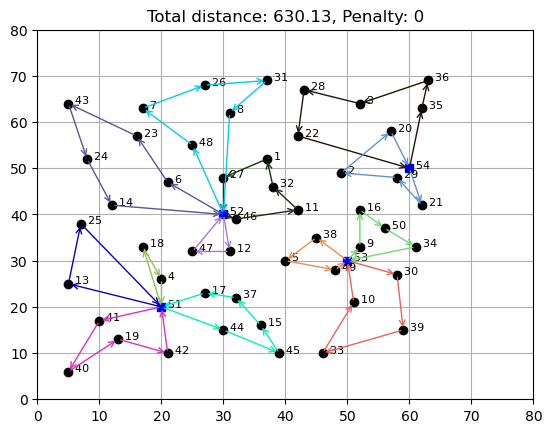

In [6]:
# Fix the rng for the colours.
fixed_rng = np.random.default_rng(756983756837456289375)

# Create a new figure.
fig = plt.figure()
ax = fig.add_subplot(111)

for optimal_k, cluster_k in zip(optimal_solutions,
                                depot_clusters):
    depot_k = cluster_k.depot

    n_vehicles = depot_k.vehicles
    
    customers_k = cluster_k.customers

    n_customers = len(customers_k)

    # Add the customers.
    for c in customers_k:
        ax.plot(c.x, c.y, 'ko')
        ax.annotate(f'  {c.ID}', xy=(c.x, c.y), fontsize=8)
    # _end_for_

    # Add the depot.
    ax.plot(depot_k.x, depot_k.y, 'bs')
    ax.annotate(f'  {depot_k.ID}',
                xy=(depot_k.x, depot_k.y), fontsize=8)

    # Reshape the solution array.
    final_k = np.reshape(optimal_k.values(),
                         (n_customers, n_vehicles))

    # Start computing the total cost.
    for i in range(n_vehicles):
        # Exclude the negative entries.
        customer_ids = final_k[final_k[:, i] >= 0, i]

        # If the array is emtpy
        # continue to the next.
        if customer_ids.size == 0:
            continue

        # Initialize the route using
        # the depot as starting point.
        route = [depot_k]

        # Start printing the route info.
        print(f"Depot[{depot_k.ID}]", end="")

        # Generate the route for this vehicle.
        for c_id in customer_ids.tolist():
            for customer_i in customers_k:
                if customer_i.ID == c_id:
                    route.append(customer_i)
        # _end_for_

        # Get the length of the route.
        n_stops = len(route)

        # Generate a random colour for the route.
        color_i = fixed_rng.random(3)
        
        # Iterate through the route.
        for j, start_point in enumerate(route):
            # Get the coordinates of the first point.
            xj, yj = start_point.x, start_point.y
    
            # The next index ('k') should point
            # at the beginning of the list once
            # we reach at the end.
            k = j + 1 if j < n_stops - 1 else 0
    
            # Get the coordinates of the both points.
            xk, yk = route[k].x, route[k].y
    
            # Put an arrow to show direction.
            ax.annotate("", xy=(xj, yj), xytext=(xk, yk),
                        arrowprops=dict(arrowstyle="<-",
                                        color=color_i))
            # Print the next stop.
            print(f" -> [{route[k].ID}]", end="")
        # _end_for_

        # Print a new line to declutter the screen.
        print(" ")
# _end_for_

ax.grid()
ax.set_xlim([0, 80])
ax.set_ylim([0, 80])

plt.title(f"Total distance: {total_d:.2f}, Penalty: {total_p}")

# Save the figure.
plt.savefig("MDVRP_cluster.pdf", format="pdf", dpi=300)

### End-Of-File